In [1]:
import pandas as pd
import scanpy as sc
from utils.io import read_anndata
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dask import array as da
from tqdm.dask import TqdmCallback

from utils.io import read_anndata

adata = read_anndata(
    '/Volumes/Extreme SSD/BA_datasets/Steuernagel2022.h5ad',
    # X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

dask: False, backed: False
Read slot "obs", store as "obs"...


/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...


In [2]:
adata.obs["tissue"].unique()

['hypothalamus']
Categories (1, object): ['hypothalamus']

In [3]:
adata

AnnData object with n_obs × n_vars = 384925 × 51216
    obs: 'SRA_ID', 'Sample_ID', 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'Dataset', 'Batch_ID', 'nCount_RNA', 'nFeature_RNA', 'percent_mt', 'C7_named', 'C25_named', 'C66_named', 'C185_named', 'C286_named', 'C465_named', 'Author_Class_Curated', 'Author_CellType', 'Region_summarized', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'features', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    obsm: 'X_umap'

In [4]:
adata.obs["cell_type"].nunique()

13

In [5]:
adata.obs["donor_id"].nunique()

24

In [6]:
adata.obs["Batch_ID"].nunique()

29

In [7]:
adata.obs["Sample_ID"].nunique()

126

In [9]:
adata.obs[["Batch_ID", "donor_id"]].drop_duplicates().value_counts("Batch_ID")

Batch_ID
RossiDropseq_batch_1        12
Mousebrainorg10x_batch_1     7
Mousebrainorg10x_batch_2     4
Affinati10x_batch_2          1
Affinati10x_batch_1          1
CampbellDropseq_batch_1      1
CampbellDropseq_batch_2      1
ChenDropseq_batch_1          1
Dowsett10xnuc_batch_1        1
Dowsett10xnuc_batch_2        1
Affinati10x_batch_3          1
Affinati10x_batch_4          1
Anderson10x_batch_1          1
Kim10x_batch_1               1
Flynn10x_batch_2             1
Flynn10x_batch_1             1
LeeDropseq_batch_1           1
Moffit10x_batch_3            1
Mickelsen10x_batch_1         1
Moffit10x_batch_1            1
Moffit10x_batch_2            1
Morris10x_batch_3            1
Morris10x_batch_2            1
Morris10x_batch_1            1
RomanovDev10x_batch_1        1
Rupp10x_batch_1              1
kimDev10x_batch_1            1
wen10x_batch_1               1
wenDropseq_batch_1           1
Name: count, dtype: int64

In [10]:
adata.obs[["Batch_ID", "donor_id"]].drop_duplicates().value_counts("donor_id")

donor_id
pooled        26
SRR6854065     1
SRR6854077     1
SRR6854066     1
SRR6854090     1
SRR6854135     1
SRR6854136     1
SRR6854080     1
SRR6854141     1
SRR6854142     1
SRR6854160     1
SRR6854157     1
SRR9000481     1
SRR9000482     1
SRR9000483     1
SRR9000480     1
SRR9000484     1
SRR9000485     1
SRR9000487     1
SRR9000486     1
SRR9000488     1
SRR9000489     1
SRR9000491     1
SRR9000492     1
Name: count, dtype: int64

seems like donor_id should be named as library_id..

In [2]:
batch_size = adata.obs["donor_id"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")
print(f"Coefficient of variance: {std/mean:.2f}")

Mean batch size: 16038.54
Standard deviation: 70520.40
Minimum batch size: 158
Maximum batch size: 354212
Coefficient of variance: 4.40


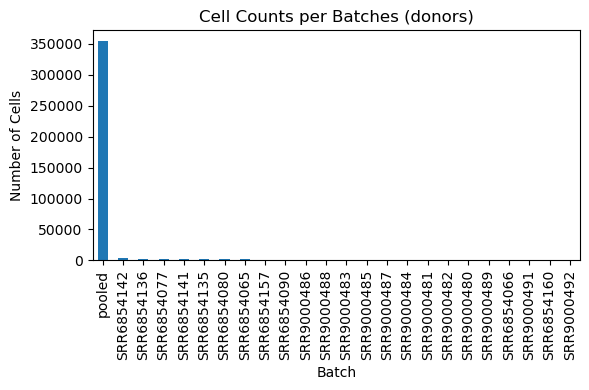

In [12]:
plt.figure(figsize=(6, 4))
batch_size.plot(kind='bar')
plt.title("Cell Counts per Batches (donors)")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [3]:
def gini_py(values):
    """
    Compute the Gini coefficient of a list of non-negative numbers.
    Pure Python implementation (no NumPy).
    """
    values = list(values)

    if any(v < 0 for v in values):
        raise ValueError("All values must be non-negative.")

    if all(v == 0 for v in values):
        return 0.0

    # Sort values
    values.sort()
    n = len(values)
    total = sum(values)

    cumulative = 0
    weighted_sum = 0
    for i, v in enumerate(values, start=1):
        weighted_sum += (2 * i - n - 1) * v

    return weighted_sum / (n * total)

print(gini_py(batch_size))

0.9080378212205841
